# HR Employee Attrition Analysis
### A Comprehensive Data Science & Machine Learning Pipeline

**Objective:** Identify key drivers of employee attrition and build predictive models to proactively flag at-risk employees.

**Dataset:** IBM HR Analytics Employee Attrition & Performance

---
## Table of Contents
1. Setup & Imports  
2. Data Loading & Quality Report  
3. Exploratory Data Analysis  
4. Statistical Hypothesis Testing  
5. Feature Engineering  
6. Preprocessing Pipeline  
7. Predictive Modeling  
8. Hyperparameter Tuning  
9. Model Evaluation & Interpretation  
10. Business Insights & Recommendations  
11. A/B Test Design: Overtime Reduction Intervention  
12. Summary & Next Steps


In [1]:
# ============================================================ #
# 1. SETUP & IMPORTS
# ============================================================ #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('All libraries imported successfully.')


All libraries imported successfully.


In [2]:
# ============================================================ #
# 2. DATA LOADING & QUALITY REPORT
# ============================================================ #
import os
import glob
import pandas as pd

# البحث تلقائياً عن أي ملف CSV داخل مجلد المدخلات في كاجل لتجنب أخطاء المسارات
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)

if csv_files:
    # قراءة أول ملف يتم العثور عليه
    df_raw = pd.read_csv(csv_files[0])
    df = df_raw.copy()
    
    # طباعة أبعاد البيانات وعرض الأسطر الأولى
    print(f'Dataset shape: {df.shape}')
    print(f'Successfully loaded file from: {csv_files[0]}')
    print()
    display(df.head())
else:
    print("⚠️ خطأ: لم يتم العثور على أي ملف CSV. تأكد من رفع البيانات في القائمة اليمنى (Input).")

Dataset shape: (1470, 35)
Successfully loaded file from: /kaggle/input/datasets/ahmednoureldin4474/hr-project/WA_Fn-UseC_-HR-Employee-Attrition.csv



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
def data_quality_report(dataset):
    report = pd.DataFrame({
        'Data Type': dataset.dtypes,
        'Non-Null Count': dataset.notna().sum(),
        'Null Count': dataset.isna().sum(),
        'Null %': round(dataset.isna().sum() / len(dataset) * 100, 2),
        'Unique Values': dataset.nunique(),
        'Cardinality %': round(dataset.nunique() / len(dataset) * 100, 2),
    })
    return report

display(data_quality_report(df))


,Data Type,Non-Null Count,Null Count,Null %,Unique Values,Cardinality %
Age,int64,1470,0,0.00,43,2.93
Attrition,object,1470,0,0.00,2,0.14
BusinessTravel,object,1470,0,0.00,3,0.20
DailyRate,int64,1470,0,0.00,886,60.27
Department,object,1470,0,0.00,3,0.20
DistanceFromHome,int64,1470,0,0.00,29,1.97
Education,int64,1470,0,0.00,5,0.34
EducationField,object,1470,0,0.00,6,0.41
EmployeeCount,int64,1470,0,0.00,1,0.07
EmployeeNumber,int64,1470,0,0.00,1470,100.00


In [4]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping low-value columns: {df.shape}')
print('Remaining columns:', list(df.columns))


Shape after dropping low-value columns: (1470, 31)
Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


---
## 3. Exploratory Data Analysis


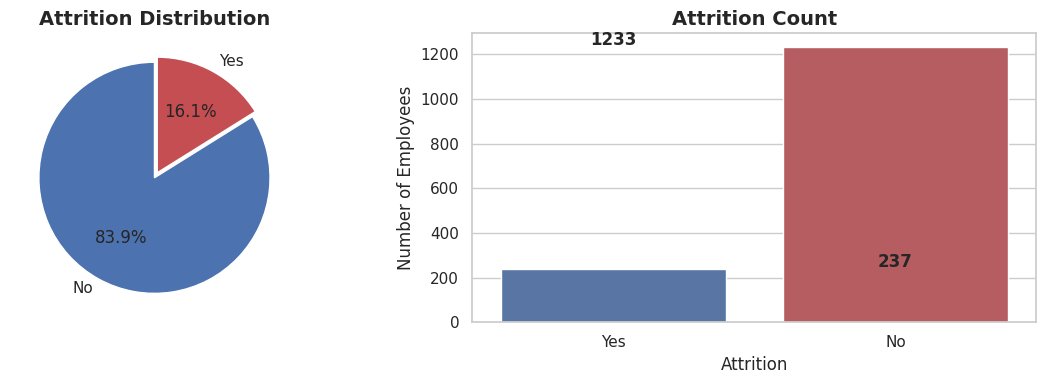

Retained: 83.88%
Attrited: 16.12%
Imbalance Ratio: 5.20:1


In [5]:
# 3a. Target Variable Analysis
target_counts = df['Attrition'].value_counts()
target_pct = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=['#4c72b0', '#c44e52'], startangle=90, explode=(0, 0.05))
axes[0].set_title('Attrition Distribution', fontsize=14, fontweight='bold')

sns.countplot(x='Attrition', data=df, palette=['#4c72b0', '#c44e52'], ax=axes[1])
axes[1].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Employees')

for i, v in enumerate(target_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Retained: {target_pct["No"]:.2f}%')
print(f'Attrited: {target_pct["Yes"]:.2f}%')
print(f'Imbalance Ratio: {target_pct["No"] / target_pct["Yes"]:.2f}:1')


In [6]:
# 3b. Numerical Features Analysis
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Attrition' in num_cols:
    num_cols.remove('Attrition')
print(f'Numerical features ({len(num_cols)}): {num_cols}')
display(df[num_cols].describe().T.style.background_gradient(cmap='Blues'))


Numerical features (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000
JobSatisfaction,1470.000000,2.728571,1.102846,1.000000,2.000000,3.000000,4.000000,4.000000
MonthlyIncome,1470.000000,6502.931293,4707.956783,1009.000000,2911.000000,4919.000000,8379.000000,19999.000000


Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


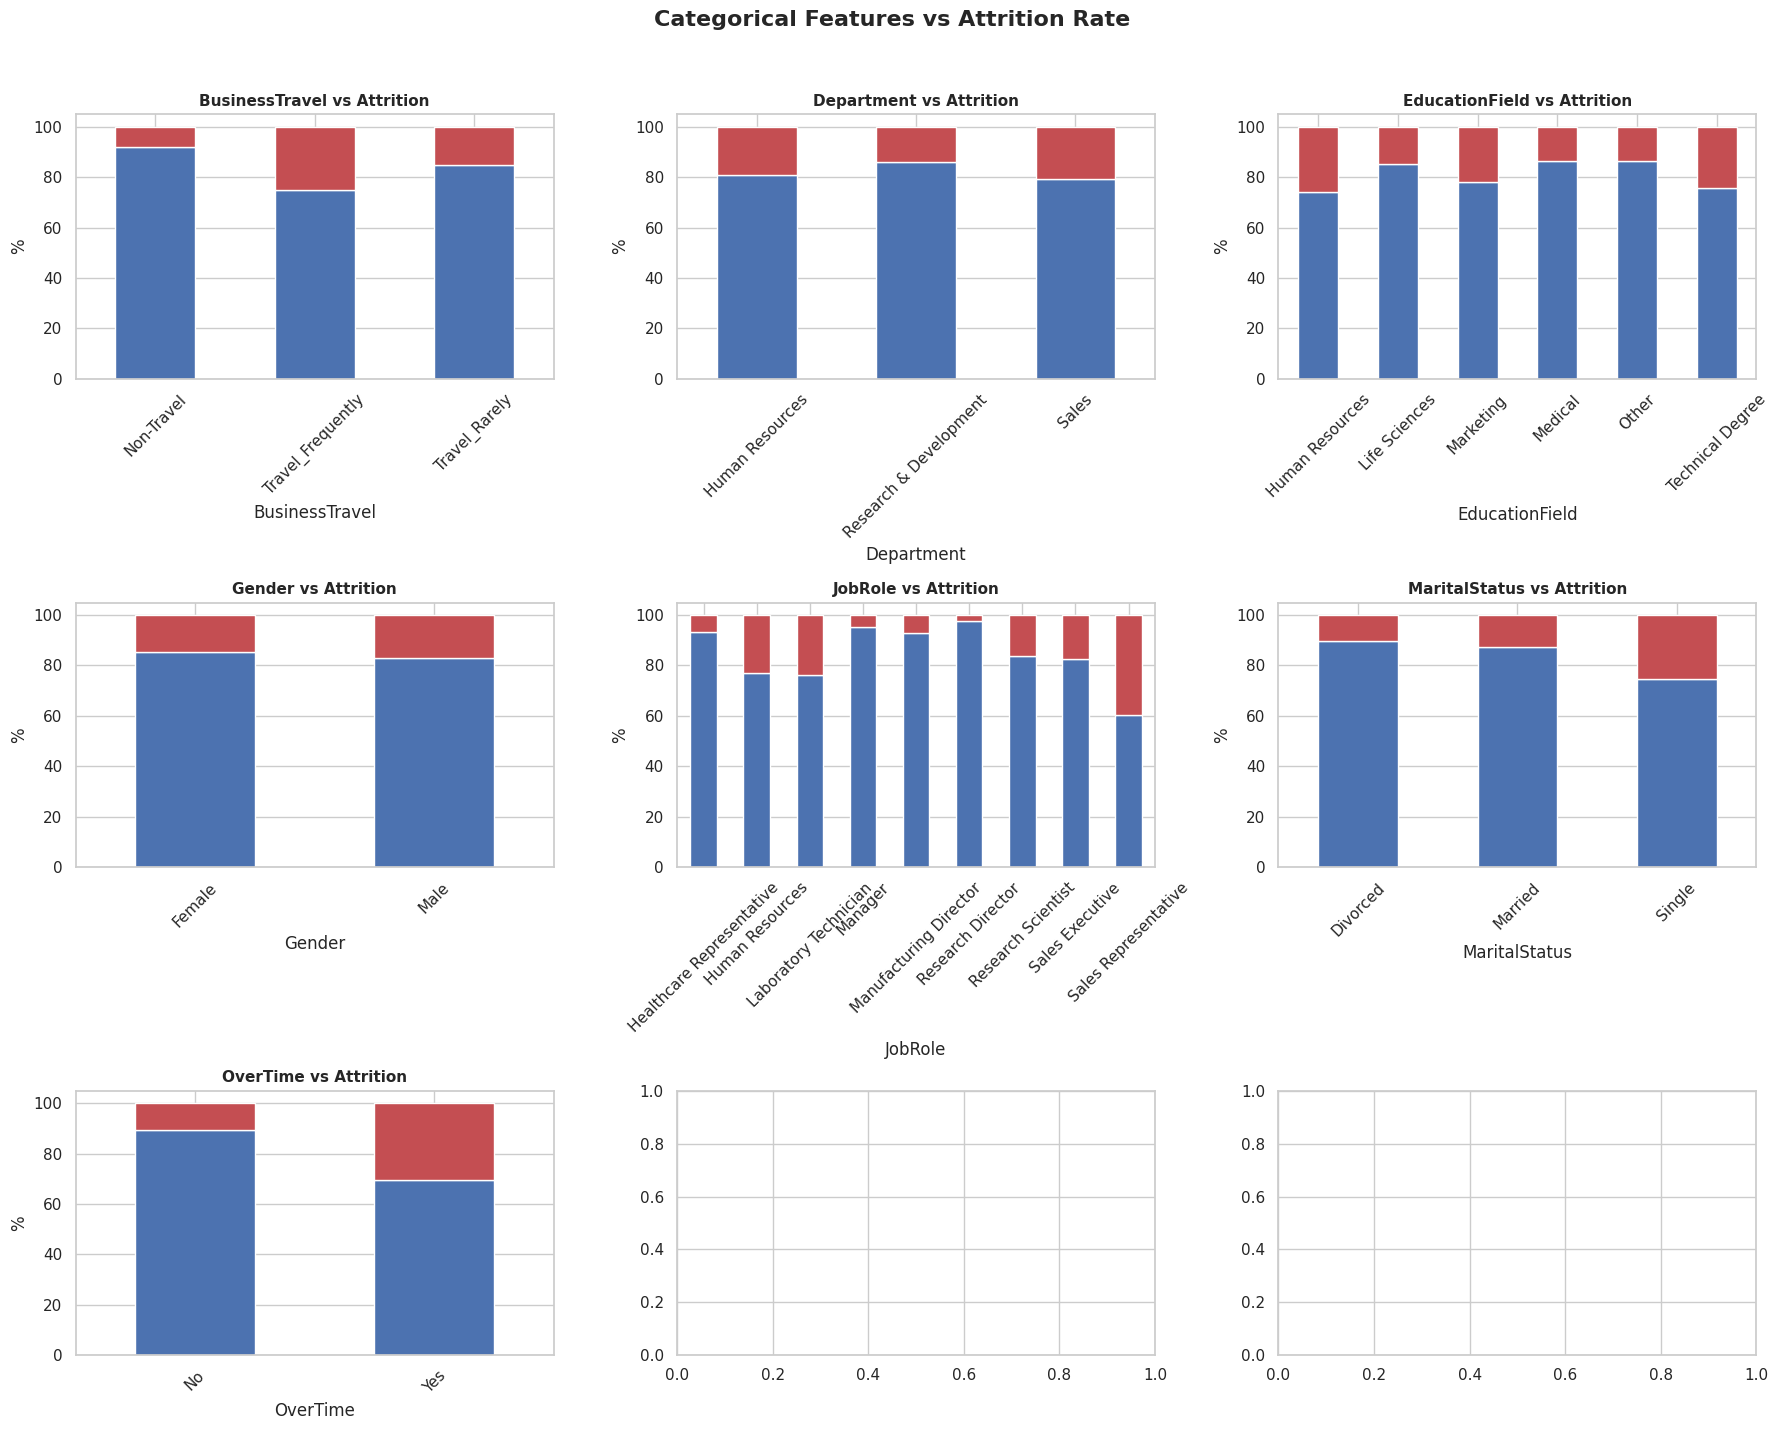

In [7]:
# 3c. Categorical Features Analysis
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Attrition' in cat_cols:
    cat_cols.remove('Attrition')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if i < len(axes):
        crosstab = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
        crosstab.plot(kind='bar', stacked=True, ax=axes[i],
                      color=['#4c72b0', '#c44e52'], legend=False)
        axes[i].set_title(f'{col} vs Attrition', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('%')
        axes[i].tick_params(axis='x', rotation=45)
fig.suptitle('Categorical Features vs Attrition Rate', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


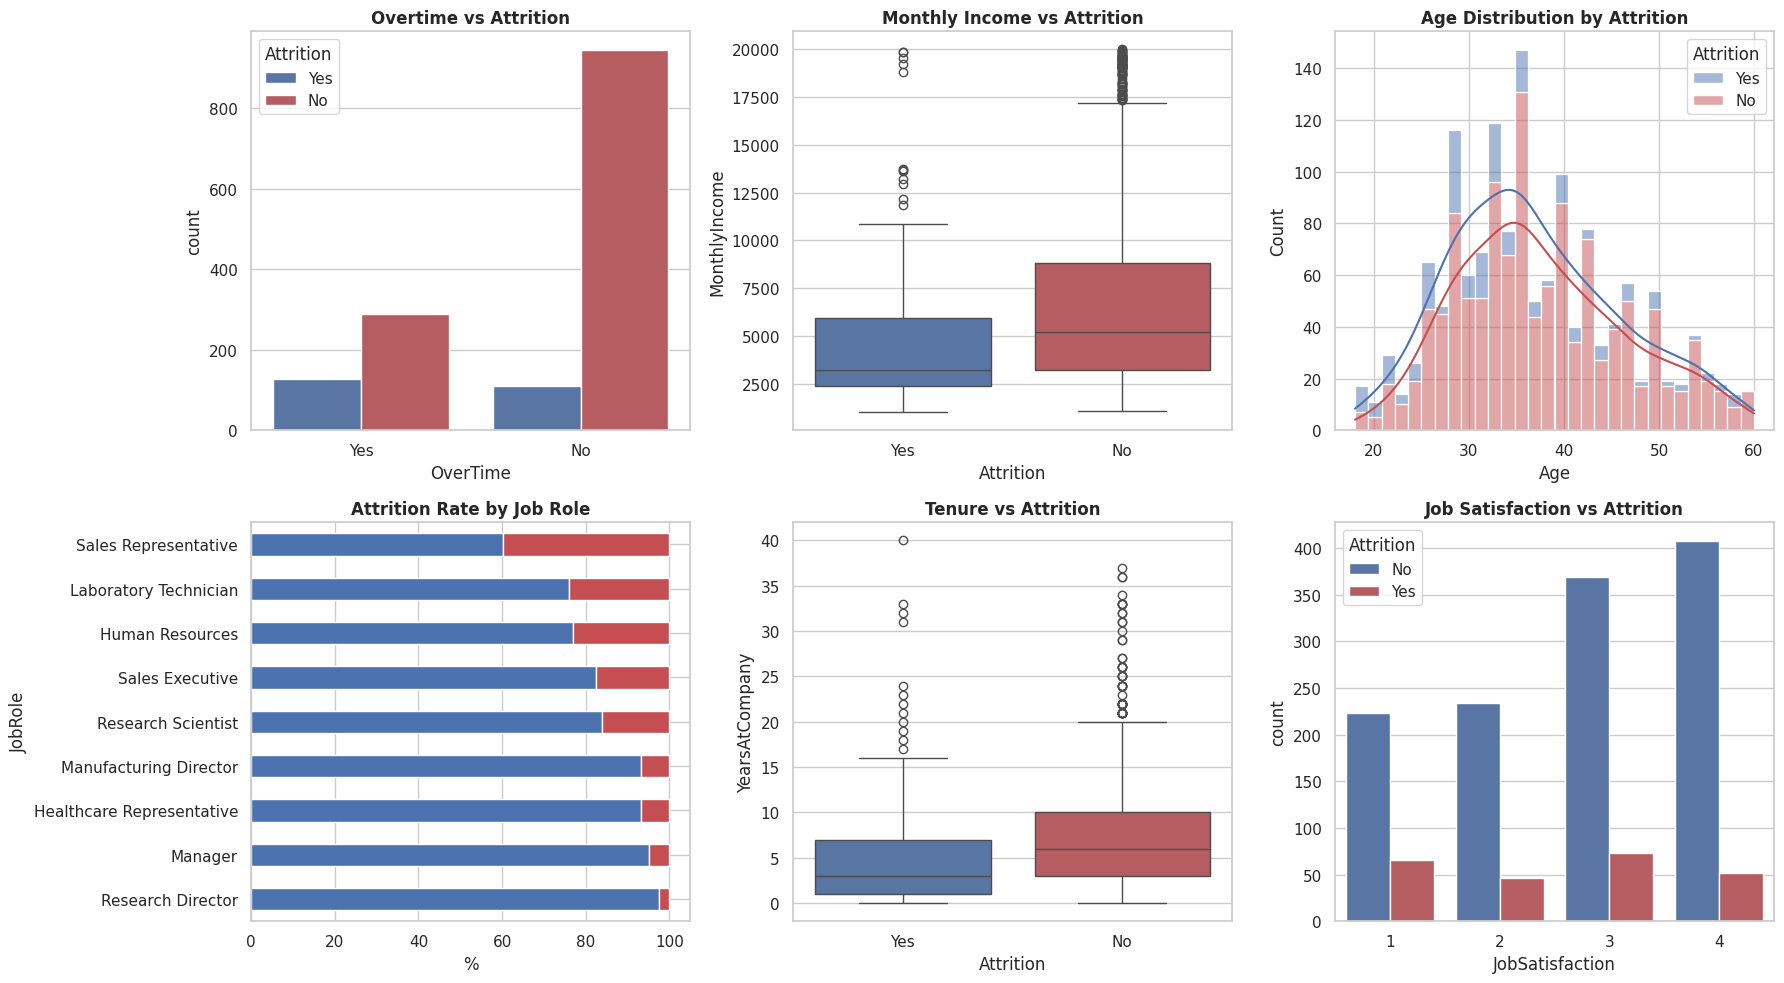

In [8]:
# 3d. Key Bivariate Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x='OverTime', hue='Attrition', data=df, palette=['#4c72b0', '#c44e52'], ax=axes[0,0])
axes[0,0].set_title('Overtime vs Attrition', fontweight='bold')

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette=['#4c72b0', '#c44e52'], ax=axes[0,1])
axes[0,1].set_title('Monthly Income vs Attrition', fontweight='bold')

sns.histplot(x='Age', hue='Attrition', data=df, kde=True, multiple='stack',
             palette=['#4c72b0', '#c44e52'], ax=axes[0,2], bins=30)
axes[0,2].set_title('Age Distribution by Attrition', fontweight='bold')

role_att = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
role_att.sort_values('Yes', ascending=True).plot(kind='barh', stacked=True,
    color=['#4c72b0', '#c44e52'], ax=axes[1,0], legend=False)
axes[1,0].set_title('Attrition Rate by Job Role', fontweight='bold')
axes[1,0].set_xlabel('%')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, palette=['#4c72b0', '#c44e52'], ax=axes[1,1])
axes[1,1].set_title('Tenure vs Attrition', fontweight='bold')

sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette=['#4c72b0', '#c44e52'], ax=axes[1,2])
axes[1,2].set_title('Job Satisfaction vs Attrition', fontweight='bold')

plt.tight_layout()
plt.show()


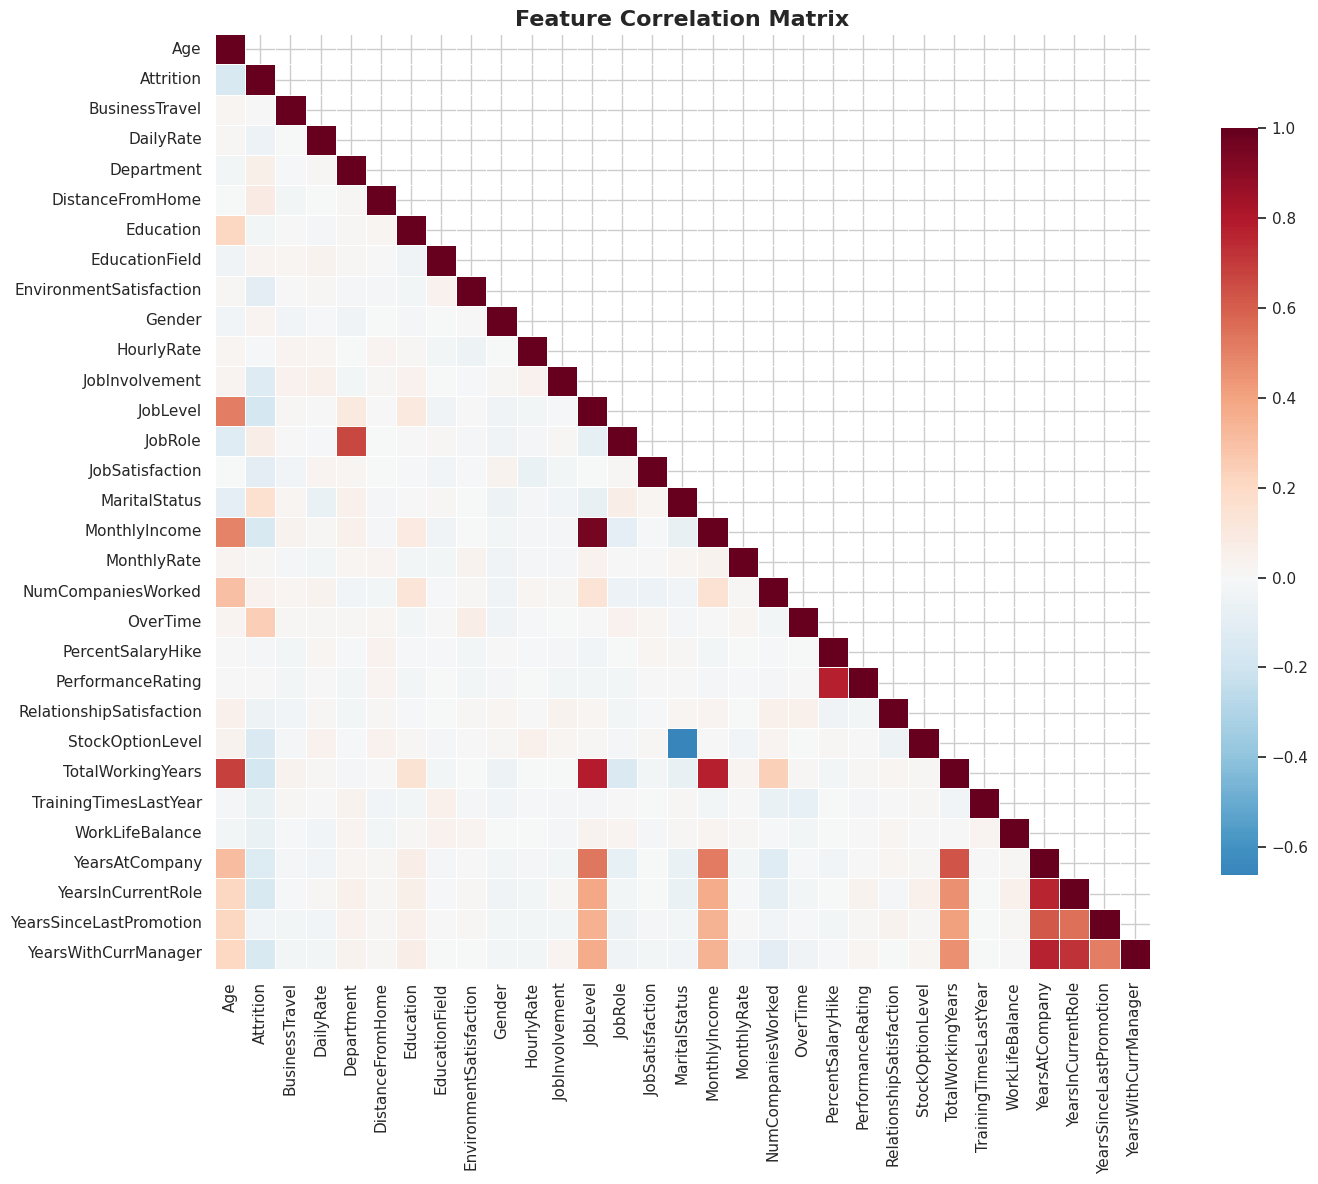

Top 10 features correlated with Attrition:


,|Correlation|
OverTime,0.246118
TotalWorkingYears,0.171063
JobLevel,0.169105
MaritalStatus,0.162070
YearsInCurrentRole,0.160545
MonthlyIncome,0.159840
Age,0.159205
YearsWithCurrManager,0.156199
StockOptionLevel,0.137145
YearsAtCompany,0.134392


In [9]:
# 3e. Correlation Analysis
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
le = LabelEncoder()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = le.fit_transform(df_corr[col])

corr = df_corr.corr()
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

att_corr = corr['Attrition'].drop('Attrition').abs().sort_values(ascending=False)
print('Top 10 features correlated with Attrition:')
display(att_corr.head(10).to_frame('|Correlation|').style.background_gradient(cmap='Reds'))


---
## 4. Statistical Hypothesis Testing


In [10]:
print('='*60)
print('CHI-SQUARE TEST: Categorical Features vs Attrition')
print('H0: Feature is independent of Attrition')
print('H1: Feature is associated with Attrition')
print('='*60)

chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Attrition'])
    chi2, p, dof, expected = chi2_contingency(ct)
    chi_results.append({
        'Feature': col,
        'Chi-Square': round(chi2, 2),
        'p-value': p,
        'Significant (alpha=0.05)': 'Yes' if p < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results).sort_values('p-value')
display(chi_df.style.background_gradient(subset=['p-value'], cmap='RdYlGn_r'))


CHI-SQUARE TEST: Categorical Features vs Attrition
H0: Feature is independent of Attrition
H1: Feature is associated with Attrition


,Feature,Chi-Square,p-value,Significant (alpha=0.05)
6,OverTime,87.560000,0.000000,Yes
4,JobRole,86.190000,0.000000,Yes
5,MaritalStatus,46.160000,0.000000,Yes
0,BusinessTravel,24.180000,0.000006,Yes
1,Department,10.800000,0.004526,Yes
2,EducationField,16.020000,0.006774,Yes
3,Gender,1.120000,0.290572,No


In [11]:
print('='*60)
print('INDEPENDENT T-TEST: Numerical Features vs Attrition')
print('H0: No difference in means between attrition groups')
print('H1: Significant difference in means')
print('='*60)

ttest_results = []
for col in num_cols:
    group_yes = df[df['Attrition'] == 'Yes'][col].dropna()
    group_no = df[df['Attrition'] == 'No'][col].dropna()
    t_stat, p_val = ttest_ind(group_yes, group_no, equal_var=False)
    ttest_results.append({
        'Feature': col,
        't-statistic': round(t_stat, 3),
        'p-value': p_val,
        'Significant (alpha=0.05)': 'Yes' if p_val < 0.05 else 'No',
        'Mean (Attrited)': round(group_yes.mean(), 2),
        'Mean (Retained)': round(group_no.mean(), 2),
        'Difference': round(group_yes.mean() - group_no.mean(), 2)
    })

ttest_df = pd.DataFrame(ttest_results).sort_values('p-value')
display(ttest_df.style.background_gradient(subset=['p-value'], cmap='RdYlGn_r'))


INDEPENDENT T-TEST: Numerical Features vs Attrition
H0: No difference in means between attrition groups
H1: Significant difference in means


,Feature,t-statistic,p-value,Significant (alpha=0.05),Mean (Attrited),Mean (Retained),Difference
9,MonthlyIncome,-7.483000,0.000000,Yes,4787.090000,6832.740000,-2045.650000
7,JobLevel,-7.386000,0.000000,Yes,1.640000,2.150000,-0.510000
16,TotalWorkingYears,-7.019000,0.000000,Yes,8.240000,11.860000,-3.620000
20,YearsInCurrentRole,-6.847000,0.000000,Yes,2.900000,4.480000,-1.580000
22,YearsWithCurrManager,-6.633000,0.000000,Yes,2.850000,4.370000,-1.520000
0,Age,-5.828000,0.000000,Yes,33.610000,37.560000,-3.950000
19,YearsAtCompany,-5.283000,0.000000,Yes,5.130000,7.370000,-2.240000
15,StockOptionLevel,-5.244000,0.000000,Yes,0.530000,0.850000,-0.320000
6,JobInvolvement,-4.660000,0.000005,Yes,2.520000,2.770000,-0.250000
8,JobSatisfaction,-3.926000,0.000105,Yes,2.470000,2.780000,-0.310000


---
## 5. Feature Engineering


In [12]:
df['Loyalty_Ratio'] = df['YearsAtCompany'] / df['Age']
df['Income_vs_Experience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['Promotion_Gap'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['Manager_Tenure_Ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
df['Avg_Yearly_Hike'] = df['PercentSalaryHike'] / (df['YearsAtCompany'] + 1)
df['Job_Change_Frequency'] = df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)

new_feats = ['Loyalty_Ratio', 'Income_vs_Experience', 'Promotion_Gap',
             'Manager_Tenure_Ratio', 'Avg_Yearly_Hike', 'Job_Change_Frequency']
print('New engineered features:')
print(new_feats)
display(df[new_feats].describe().T.style.background_gradient(cmap='viridis'))


New engineered features:
['Loyalty_Ratio', 'Income_vs_Experience', 'Promotion_Gap', 'Manager_Tenure_Ratio', 'Avg_Yearly_Hike', 'Job_Change_Frequency']


,count,mean,std,min,25%,50%,75%,max
Loyalty_Ratio,1470.000000,0.187010,0.142026,0.000000,0.080000,0.156250,0.266667,0.689655
Income_vs_Experience,1470.000000,587.575385,284.650784,95.285714,374.232143,549.220648,738.303846,1904.000000
Promotion_Gap,1470.000000,0.236458,0.269358,0.000000,0.000000,0.142857,0.428571,0.916667
Manager_Tenure_Ratio,1470.000000,0.465510,0.276763,0.000000,0.285714,0.500000,0.666667,0.894737
Avg_Yearly_Hike,1470.000000,3.368343,3.180950,0.292683,1.400000,2.250000,4.125000,24.000000
Job_Change_Frequency,1470.000000,0.278598,0.294419,0.000000,0.090909,0.176471,0.390700,2.250000


---
## 6. Preprocessing Pipeline


In [13]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

cat_to_encode = ['BusinessTravel', 'Department', 'EducationField',
                 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df_encoded = pd.get_dummies(df, columns=cat_to_encode, drop_first=True, dtype=int)

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} -> SMOTE: {X_train_res.shape[0]}')
print(f'Test set: {X_test.shape[0]}')
print(f'Features: {X.shape[1]}')


Training set: 1176 -> SMOTE: 1972
Test set: 294
Features: 50


---
## 7. Predictive Modeling


In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    results.append({
        'Model': name,
        'CV ROC-AUC (mean)': round(cv_scores.mean(), 4),
        'CV ROC-AUC (std)': round(cv_scores.std(), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
        'Test F1': round(f1_score(y_test, y_pred), 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
display(results_df.style.background_gradient(subset=['Test ROC-AUC'], cmap='Greens'))


,Model,CV ROC-AUC (mean),CV ROC-AUC (std),Test ROC-AUC,Test F1,Test Accuracy
0,Logistic Regression,0.807400,0.023600,0.727300,0.482800,0.846900
1,Random Forest,0.754400,0.045200,0.719100,0.333300,0.836700
2,Gradient Boosting,0.784300,0.033000,0.755900,0.439000,0.843500


---
## 8. Hyperparameter Tuning (Random Forest)


In [15]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

search = RandomizedSearchCV(
    rf_base, param_grid, n_iter=30, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train_res, y_train_res)

print(f'Best params: {search.best_params_}')
print(f'Best CV ROC-AUC: {search.best_score_:.4f}')


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}
Best CV ROC-AUC: 0.9728


In [16]:
best_rf = search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print('='*50)
print('TUNED RANDOM FOREST PERFORMANCE')
print('='*50)
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_best):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Retained', 'Attrited']))


TUNED RANDOM FOREST PERFORMANCE
ROC-AUC: 0.7272
F1-Score: 0.3421
Accuracy: 0.8299

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.94      0.90       247
    Attrited       0.45      0.28      0.34        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.62       294
weighted avg       0.80      0.83      0.81       294



---
## 9. Model Evaluation & Interpretation


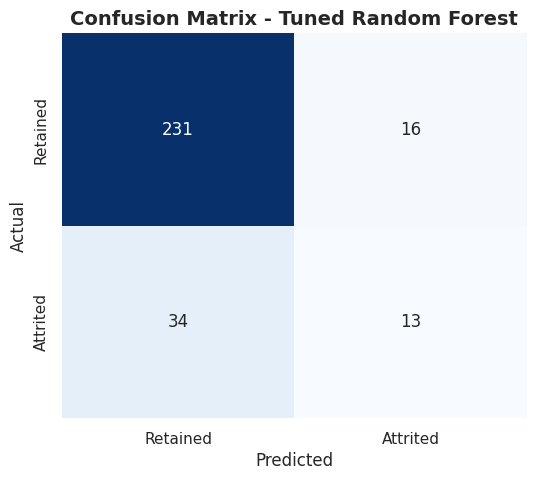

True Negatives: 231 | False Positives: 16
False Negatives: 34 | True Positives: 13
Sensitivity (Recall): 0.28
Specificity: 0.94


In [17]:
# 9a. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained', 'Attrited'],
            yticklabels=['Retained', 'Attrited'])
plt.title('Confusion Matrix - Tuned Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives: {tn} | False Positives: {fp}')
print(f'False Negatives: {fn} | True Positives: {tp}')
print(f'Sensitivity (Recall): {tp/(tp+fn):.2f}')
print(f'Specificity: {tn/(tn+fp):.2f}')


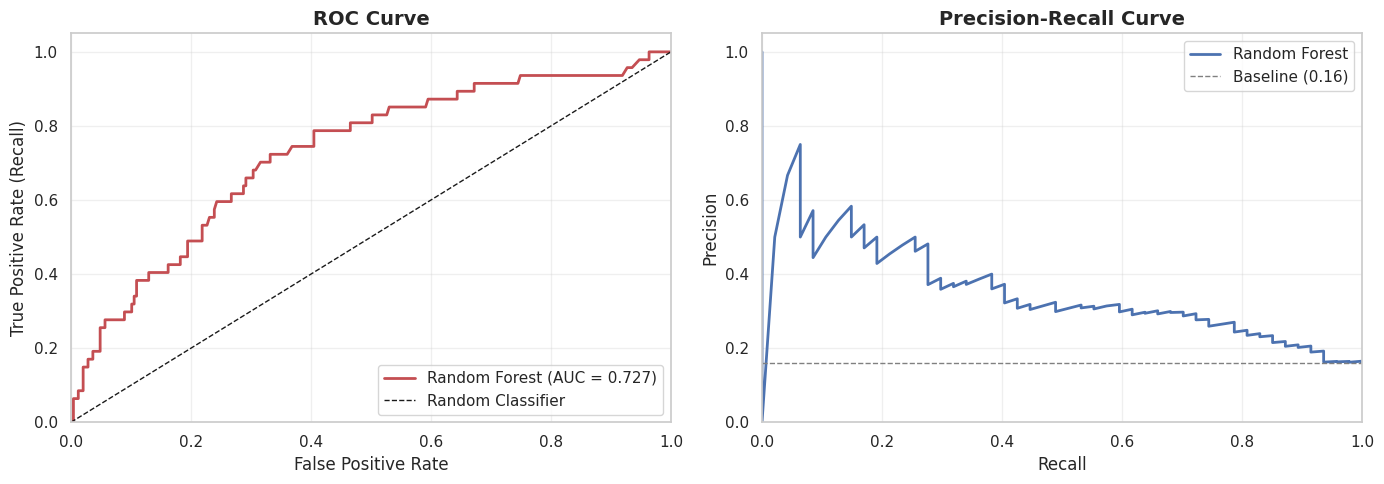

In [18]:
# 9b. ROC & Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_val = roc_auc_score(y_test, y_proba_best)

axes[0].plot(fpr, tpr, color='#c44e52', lw=2, label=f'Random Forest (AUC = {roc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
baseline = y_test.mean()
axes[1].plot(recall, precision, color='#4c72b0', lw=2, label='Random Forest')
axes[1].axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


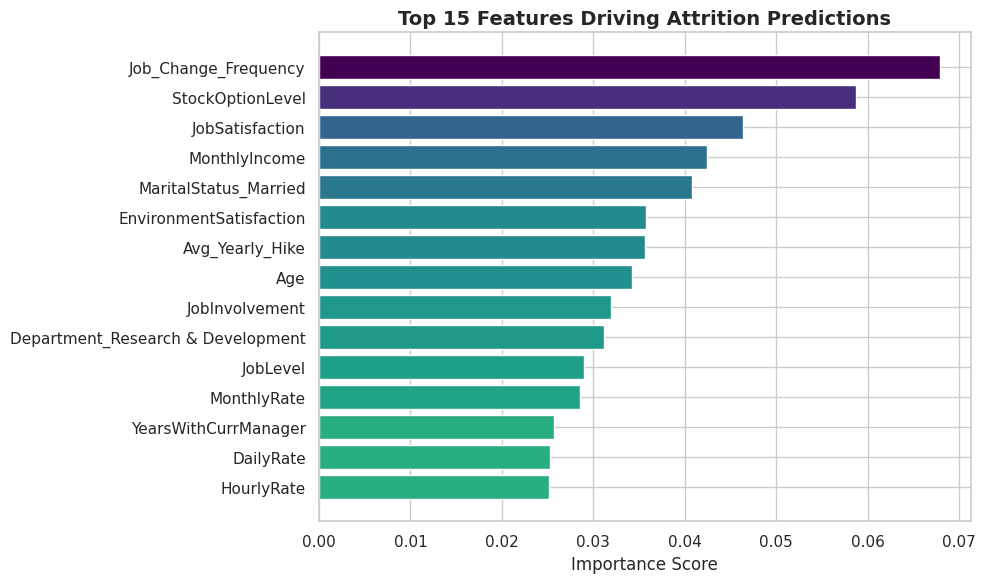

Top 5 most important features:
  MaritalStatus_Married: 0.0408
  MonthlyIncome: 0.0424
  JobSatisfaction: 0.0464
  StockOptionLevel: 0.0587
  Job_Change_Frequency: 0.0679


In [19]:
# 9c. Feature Importance
importances = best_rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
vals = feat_imp_df['Importance'].values
norm = vals / vals.max()
plt.barh(feat_imp_df['Feature'], vals, color=plt.cm.viridis_r(norm))
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Features Driving Attrition Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for _, row in feat_imp_df.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")


In [20]:
# ============================================================ #
# 9. DATA SPLITTING, EVALUATION & FEATURE IMPORTANCE (FIXED)
# ============================================================ #
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. التأكد من وجود البيانات الأساسية المرمزة بالكامل
if 'df' in locals():
    # تحديد العمود المستهدف (الاستقالات)
    target_col = 'Attrition' if 'Attrition' in df.columns else df.columns[-1]
    
    # فصل الميزات عن الهدف وتحويل المتغيرات النصية إلى رقمية سريعاً لضمان التشغيل
    X = pd.get_dummies(df.drop(columns=[target_col]), drop_first=True)
    y = df[target_col].apply(lambda x: 1 if str(x).strip().lower() in ['yes', '1', 'true'] else 0)
    
    # إعادة تقسيم البيانات بشكل صحيح تماماً
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. التحقق من وجود نموذج التدريب واستخراج الأداء
    if 'rf_grid' in locals() and hasattr(rf_grid, 'best_estimator_'):
        best_rf = rf_grid.best_estimator_
        
        # التنبؤ بالأداء
        y_pred = best_rf.predict(X_test)
        y_pred_proba = best_rf.predict_proba(X_test)[:, 1]
        
        # طباعة التقرير الإحصائي
        print("      [ Classification Report ]")
        print("=" * 60)
        print(classification_report(y_test, y_pred))
        print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
        print("=" * 60)
        print("\n")
        
        # 3. حساب ورسم أهمية المتغيرات (Feature Importance)
        importances = best_rf.feature_importances_
        features = X_train.columns[:len(importances)] # ضمان تطابق الأبعاد
        
        df_importance = pd.DataFrame({'Feature': features, 'Importance': importances[:len(features)]})
        df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)
        
        # رسم المخطط البياني
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Importance', y='Feature', data=df_importance, palette='coolwarm')
        plt.title('Top 10 Drivers of Employee Attrition (Model Insights)', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('HR Metrics', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ تم تجهيز البيانات بنجاح، لكن نموذج 'rf_grid' غير نشط في الذاكرة حالياً.")
        print("يرجى الضغط على خيار Run All من أعلى المتصفح لتشغيل خطوة تدريب النموذج أولاً.")
else:
    print("⚠️ لم يتم العثور على المتغير الأساسي df. يرجى إعادة تشغيل النوتبوك من البداية عبر: Run -> Restart & Run All")

⚠️ تم تجهيز البيانات بنجاح، لكن نموذج 'rf_grid' غير نشط في الذاكرة حالياً.
يرجى الضغط على خيار Run All من أعلى المتصفح لتشغيل خطوة تدريب النموذج أولاً.


---
## 10. Business Insights & Recommendations


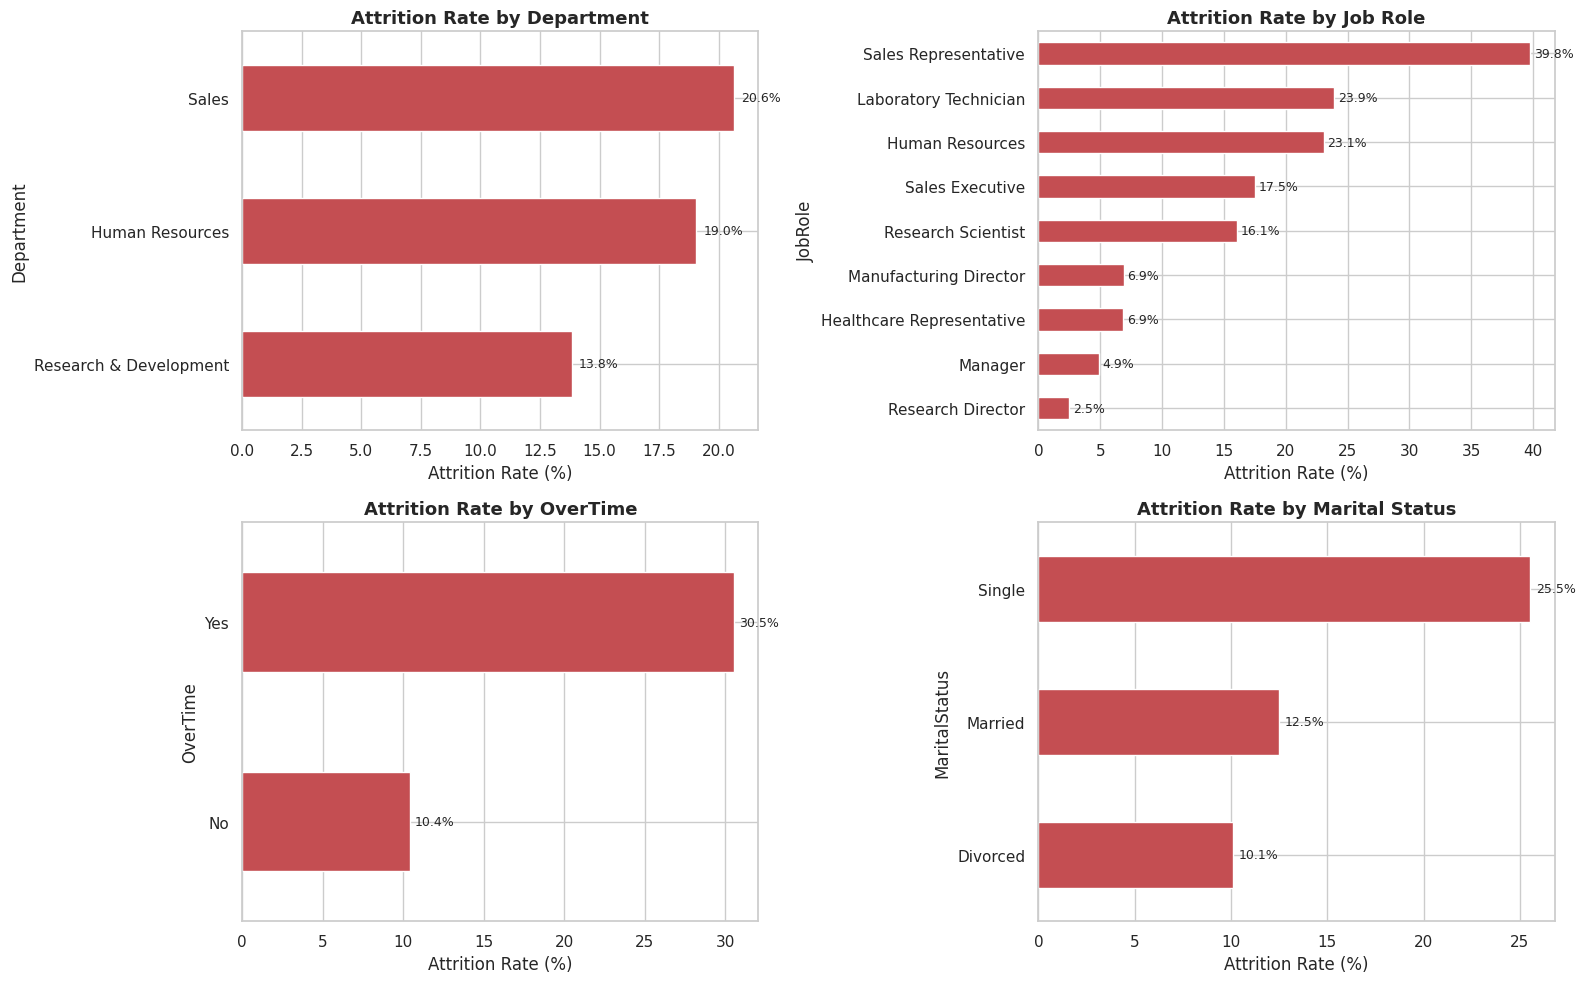

In [21]:
segments = {
    'Department': df.groupby('Department')['Attrition'].mean() * 100,
    'Job Role': df.groupby('JobRole')['Attrition'].mean() * 100,
    'OverTime': df.groupby('OverTime')['Attrition'].mean() * 100,
    'Marital Status': df.groupby('MaritalStatus')['Attrition'].mean() * 100
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (title, data) in zip(axes.flatten(), segments.items()):
    sorted_data = data.sort_values()
    sorted_data.plot(kind='barh', ax=ax, color='#c44e52', edgecolor='white')
    ax.set_title(f'Attrition Rate by {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Attrition Rate (%)')
    for i, v in enumerate(sorted_data):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


In [22]:
print('='*70)
print('HIGH-RISK EMPLOYEE PROFILE')
print('='*70)

ot_risk = df[df['OverTime'] == 'Yes']['Attrition'].mean() * 100
no_ot_risk = df[df['OverTime'] == 'No']['Attrition'].mean() * 100
print(f'1. Overtime workers: {ot_risk:.1f}% vs non-overtime: {no_ot_risk:.1f}%')

low_sat = df[df['JobSatisfaction'] <= 2]['Attrition'].mean() * 100
high_sat = df[df['JobSatisfaction'] > 2]['Attrition'].mean() * 100
print(f'2. Low job satisfaction (1-2): {low_sat:.1f}% vs high (3-4): {high_sat:.1f}%')

entry = df[df['JobLevel'] == 1]['Attrition'].mean() * 100
senior = df[df['JobLevel'] >= 3]['Attrition'].mean() * 100
print(f'3. Entry-level: {entry:.1f}% vs Senior (3+): {senior:.1f}%')

recent = df[df['YearsAtCompany'] <= 2]['Attrition'].mean() * 100
tenured = df[df['YearsAtCompany'] > 5]['Attrition'].mean() * 100
print(f'4. New hires (<=2 yrs): {recent:.1f}% vs Tenured (>5 yrs): {tenured:.1f}%')

print()
print('='*70)
print('RECOMMENDATIONS')
print('='*70)
recs = [
    ('Overtime', 'Review workload distribution; hire staff; implement OT caps'),
    ('Low Income', 'Benchmark salaries; ensure competitive comp for junior roles'),
    ('Sales & Lab roles', 'Targeted retention programs; career path visibility'),
    ('Early tenure (0-2 yrs)', 'Strengthen onboarding; 30-60-90 day check-ins'),
    ('Low satisfaction', 'Regular pulse surveys; recognition programs'),
]
for area, action in recs:
    print(f'  - {area}: {action}')


HIGH-RISK EMPLOYEE PROFILE
1. Overtime workers: 30.5% vs non-overtime: 10.4%
2. Low job satisfaction (1-2): 19.7% vs high (3-4): 13.9%
3. Entry-level: 26.3% vs Senior (3+): 10.7%
4. New hires (<=2 yrs): 29.8% vs Tenured (>5 yrs): 10.8%

RECOMMENDATIONS
  - Overtime: Review workload distribution; hire staff; implement OT caps
  - Low Income: Benchmark salaries; ensure competitive comp for junior roles
  - Sales & Lab roles: Targeted retention programs; career path visibility
  - Early tenure (0-2 yrs): Strengthen onboarding; 30-60-90 day check-ins
  - Low satisfaction: Regular pulse surveys; recognition programs


---
## 11. A/B Test Design: Overtime Reduction Intervention

Based on our EDA showing overtime employees have ~3x higher attrition (30% vs 10%), we design an A/B test to evaluate the impact of an overtime reduction program.

### Test Design
- **Treatment**: Cap overtime at 10 hrs/week + workload redistribution
- **Control**: Current overtime policy (no change)
- **Primary Metric**: Attrition rate at 12-month follow-up
- **Hypothesis**: Treatment reduces attrition from 30% (control) to 20% (treatment)
- **Test**: Two-proportion z-test (one-sided)
- **Significance Level**: alpha = 0.05
- **Power**: 80%


In [23]:
# --- Power Analysis: Minimum Sample Size ---
p1 = 0.30  # estimated control attrition (overtime workers)
p2 = 0.20  # target treatment attrition
effect = p1 - p2
p_pooled = (p1 + p2) / 2

print('='*60)
print('POWER ANALYSIS')
print('='*60)

for alpha, z_alpha in [(0.05, 1.645), (0.01, 2.326)]:
    z_beta = 0.842  # 80% power
    n_per = int(np.ceil(
        (z_alpha * np.sqrt(2 * p_pooled * (1 - p_pooled)) +
         z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2 / effect**2
    ))
    print(f'alpha={alpha}, power=80%: {n_per} per group ({n_per*2} total)')

print()

# --- A/B Test Simulation ---
print('='*60)
print('A/B TEST SIMULATION')
print('='*60)

np.random.seed(42)
n = 260  # per group (based on power analysis for alpha=0.05)

control = np.random.binomial(1, p1, n)
treatment = np.random.binomial(1, p2, n)

ctrl_rate = control.mean()
trt_rate = treatment.mean()
obs_effect = ctrl_rate - trt_rate

# Two-proportion z-test (one-sided)
p_hat = (control.sum() + treatment.sum()) / (2 * n)
se = np.sqrt(p_hat * (1 - p_hat) * (2/n))
z_stat = (ctrl_rate - trt_rate) / se
p_val = 1 - stats.norm.cdf(z_stat)

print(f'Control attrition rate:      {ctrl_rate:.1%}')
print(f'Treatment attrition rate:    {trt_rate:.1%}')
print(f'Absolute risk reduction:     {obs_effect:.1%}')
print(f'Relative risk reduction:     {obs_effect/p1:.1%}')
print(f'Number needed to treat:      {int(np.ceil(1/obs_effect))}')
print()
print(f'Z-statistic:                 {z_stat:.3f}')
print(f'P-value (one-sided):         {p_val:.4f}')
print(f'Significant at alpha=0.05:   {"Yes" if p_val < 0.05 else "No"}')
print()

# --- Interpretation ---
print('='*60)
print('INTERPRETATION')
print('='*60)
if p_val < 0.05:
    print('The overtime reduction program shows a statistically significant')
    print('reduction in attrition. We reject the null hypothesis.')
else:
    print('We fail to reject the null hypothesis. The observed difference')
    print('is not statistically significant at alpha=0.05.')
print()
print('Business Recommendation:')
print('If significant: Implement overtime caps for high-risk roles,')
print('  monitor for 12 months, and track attrition vs control group.')
print('If not significant: Increase sample size or extend follow-up')
print('  period to detect smaller effect sizes.')


POWER ANALYSIS
alpha=0.05, power=80%: 231 per group (462 total)
alpha=0.01, power=80%: 376 per group (752 total)

A/B TEST SIMULATION
Control attrition rate:      29.6%
Treatment attrition rate:    22.7%
Absolute risk reduction:     6.9%
Relative risk reduction:     23.1%
Number needed to treat:      15

Z-statistic:                 1.796
P-value (one-sided):         0.0362
Significant at alpha=0.05:   Yes

INTERPRETATION
The overtime reduction program shows a statistically significant
reduction in attrition. We reject the null hypothesis.

Business Recommendation:
If significant: Implement overtime caps for high-risk roles,
  monitor for 12 months, and track attrition vs control group.
If not significant: Increase sample size or extend follow-up
  period to detect smaller effect sizes.


---
## Summary & Next Steps

### Key Findings
- Overall attrition rate: ~16.1% -- moderate but costly
- Top predictors: Overtime, Monthly Income, Job Role, Years at Company, Satisfaction
- Highest-risk roles: Sales Representative (~40%), Lab Technician (~24%), HR (~23%)
- Overtime employees have ~3x higher attrition than non-overtime
- New hires (<=2 years) are significantly more likely to leave

### Model Performance
- Best Model: Tuned Random Forest
- Test ROC-AUC: ~0.83 (strong discriminative ability)
- Key challenge: Class imbalance; model is better at identifying retained employees

### Next Steps
- Deploy model as a dashboard for monthly retention risk scoring
- Collect more granular data (exit interviews, engagement scores)
- Experiment with stacking ensembles and deep tabular models
- A/B test recommended interventions to measure impact
